In [1]:
# Autoreload all modules
%load_ext autoreload
%autoreload 2

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp
import jax.random as jr
import pylab as plt

import sys
sys.path.append('../src')

from jax_pdf.log_gauss_pines import LGCP

In [2]:
# initialize jax RNG
key = jr.key(0)

In [3]:
# Create LGCP model (direct instantiation, no factory)
lgcp = LGCP(grid_dim=40)
print(f"Dimension: {lgcp.dim}")

Dimension: 1600


In [4]:
# Compute Laplace approximation (MAP + Hessian)
# Now includes optimization trajectory for diagnostics
laplace_approx = lgcp.laplace_approximation()

print(f"Converged: {laplace_approx['optimization']['converged']}")
print(f"Iterations: {laplace_approx['optimization']['n_iters']}")

Converged: True
Iterations: 60


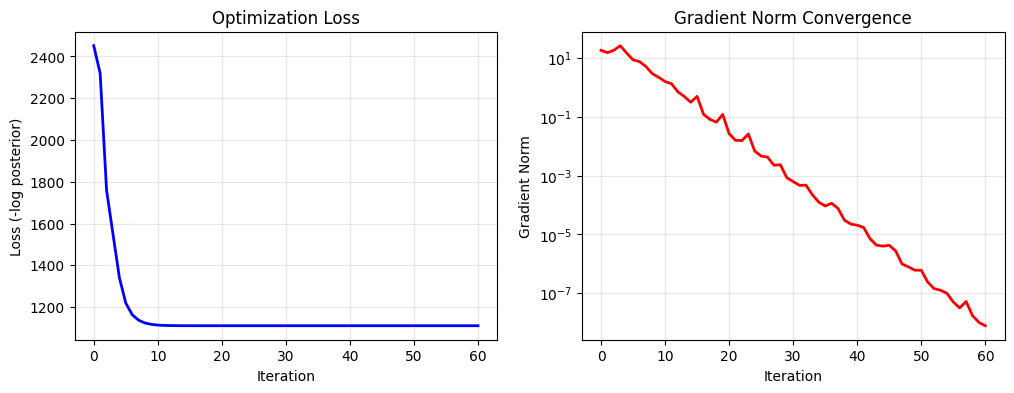

In [5]:
# Plot optimization convergence (loss and gradient norm)
opt = laplace_approx["optimization"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(opt["loss_history"], 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss (-log posterior)')
axes[0].set_title('Optimization Loss')
axes[0].grid(True, alpha=0.3)

# Gradient norm (log scale)
axes[1].semilogy(opt["grad_norm_history"], 'r-', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Gradient Norm')
axes[1].set_title('Gradient Norm Convergence')
axes[1].grid(True, alpha=0.3)

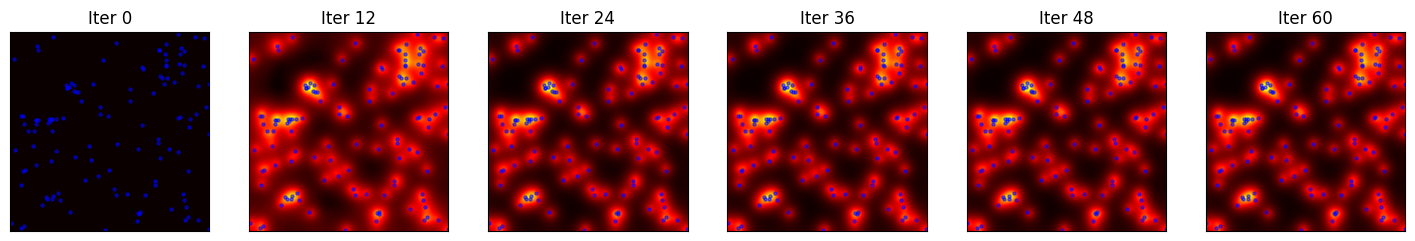

In [6]:
# Visualize optimization trajectory (snapshots at different iterations)
opt = laplace_approx["optimization"]
x_history = opt["x_history"]
n_iters = opt["n_iters"]
grid_dim = int(np.sqrt(lgcp.dim))

# Select iterations to display (initial, some intermediate, final)
n_snapshots = min(6, n_iters + 1)
snapshot_indices = np.linspace(0, n_iters, n_snapshots, dtype=int)

fig, axes = plt.subplots(1, n_snapshots, figsize=(3 * n_snapshots, 3))
pines_locations = lgcp.pines_points

for idx, (ax, iter_idx) in enumerate(zip(axes, snapshot_indices)):
    x_grid = x_history[iter_idx].reshape(grid_dim, grid_dim)
    im = ax.imshow(x_grid, cmap='hot', interpolation='bicubic', 
                   extent=[0, 1, 0, 1], origin='lower')
    ax.scatter(pines_locations[:, 1], pines_locations[:, 0],
               color='blue', marker="o", s=5, alpha=0.5)
    ax.set_title(f'Iter {iter_idx}')
    ax.set_xticks([])
    ax.set_yticks([])

In [7]:
mu_laplace = laplace_approx["mu"]
cov_laplace = laplace_approx["cov"]

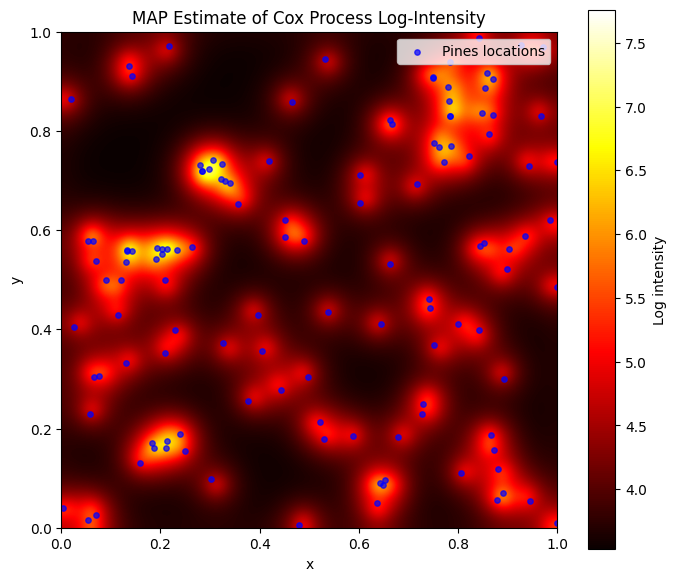

In [12]:
# MAP estimate plot
grid_dim = int(np.sqrt(lgcp.dim))
x_map_grid = mu_laplace.reshape(grid_dim, grid_dim)
pines_locations = lgcp.pines_points

plt.figure(figsize=(8, 7))
plt.imshow(x_map_grid, cmap='hot', interpolation='bicubic', extent=[0, 1, 0, 1], origin='lower')
plt.colorbar(label='Log intensity')
plt.scatter(pines_locations[:, 1], pines_locations[:, 0],
            color='blue', marker="o", s=15, alpha=0.7,
            label='Pines locations')
plt.legend(loc='upper right')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MAP Estimate of Cox Process Log-Intensity')
filename = "log_gaussian_pine_map_estimate.png"
plt.savefig(filename, dpi=150, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Posterior Marginal Std Dev (Laplace Approximation)')

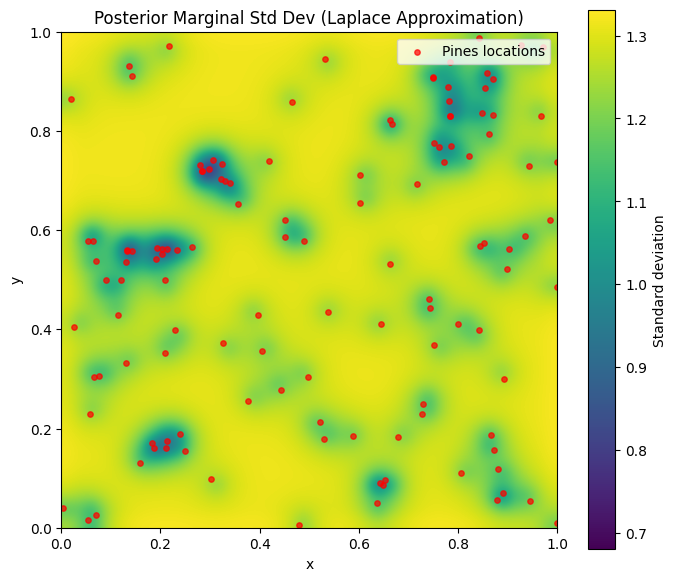

In [9]:
# Marginal standard deviation plot (Laplace approximation uncertainty)
marginal_std = np.sqrt(np.diag(cov_laplace)).reshape(grid_dim, grid_dim)

plt.figure(figsize=(8, 7))
plt.imshow(marginal_std, cmap='viridis', interpolation='bicubic', extent=[0, 1, 0, 1], origin='lower')
plt.colorbar(label='Standard deviation')
plt.scatter(pines_locations[:, 1], pines_locations[:, 0],
            color='red', marker="o", s=15, alpha=0.7,
            label='Pines locations')
plt.legend(loc='upper right')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posterior Marginal Std Dev (Laplace Approximation)')
